# 📊 Notebook 03 — Exploratory Data Analysis (EDA)

---

## Project Context

| Field | Detail |
|---|---|
| **Competition** | SATRIA DATA 2026 — Big Data Challenge |
| **Task** | Supervised Image Classification |
| **Classes** | Recyclable, Electronic, Organic |
| **Primary Metric** | Macro-averaged F1 Score |
| **Experiment** | Baseline CNN — Experiment 01 |
| **Stage** | EDA (Step 1 of 7) |

---

## Tujuan EDA

Tahap EDA bertujuan untuk **memahami dataset secara mendalam sebelum preprocessing dan modeling**.

EDA bukan sekadar visualisasi. EDA menghasilkan *evidence-based insights* yang menentukan:
- Strategi preprocessing
- Strategi data augmentasi
- Keputusan desain model
- Risiko yang perlu dimitigasi

> ⚠️ **Aturan BDC:** EDA hanya dilakukan pada dataset resmi train. Test set tidak digunakan dalam analisis ini. Tidak ada modifikasi terhadap data asli.

In [1]:
# ============================================================
# CELL 1 — IMPORTS & SETUP
# ============================================================
import sys
import json
import logging
import warnings
from pathlib import Path
import pandas as pd

warnings.filterwarnings('ignore')

# Tambahkan root proyek ke sys.path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import modul EDA dari src/
from src.eda.dataset_summary import scan_dataset, get_image_properties_df, find_duplicates
from src.eda.visualization import plot_class_distribution, plot_image_properties, plot_sample_images

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(message)s', datefmt='%H:%M:%S')
logger = logging.getLogger(__name__)
logger.info('Imports selesai.')

21:32:30 | Imports selesai.


In [2]:
# ============================================================
# CELL 2 — KONFIGURASI
# ============================================================
DATA_ROOT    = PROJECT_ROOT / 'data' / 'raw' / 'BDC2026'
TRAIN_DIR    = DATA_ROOT / 'train'
FIGURES_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
REPORTS_DIR  = PROJECT_ROOT / 'outputs' / 'reports'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    '0_Recyclable': 'Recyclable',
    '1_Electronic': 'Electronic',
    '2_Organic'   : 'Organic'
}

assert TRAIN_DIR.exists(), f'Train directory tidak ditemukan: {TRAIN_DIR}'
print(f'Train Dir : {TRAIN_DIR}')

Train Dir : D:\Data Analysis\Smart Waste Classification\data\raw\BDC2026\train


---
## Step 1 — Dataset Overview & Class Distribution
Kita memindai dataset untuk mendapatkan jumlah gambar dan distribusinya. Hal ini penting untuk mengecek *class imbalance*.


  DATASET OVERVIEW — SATRIA DATA 2026 BDC
  Total Classes : 3
  Total Images  : 26,524


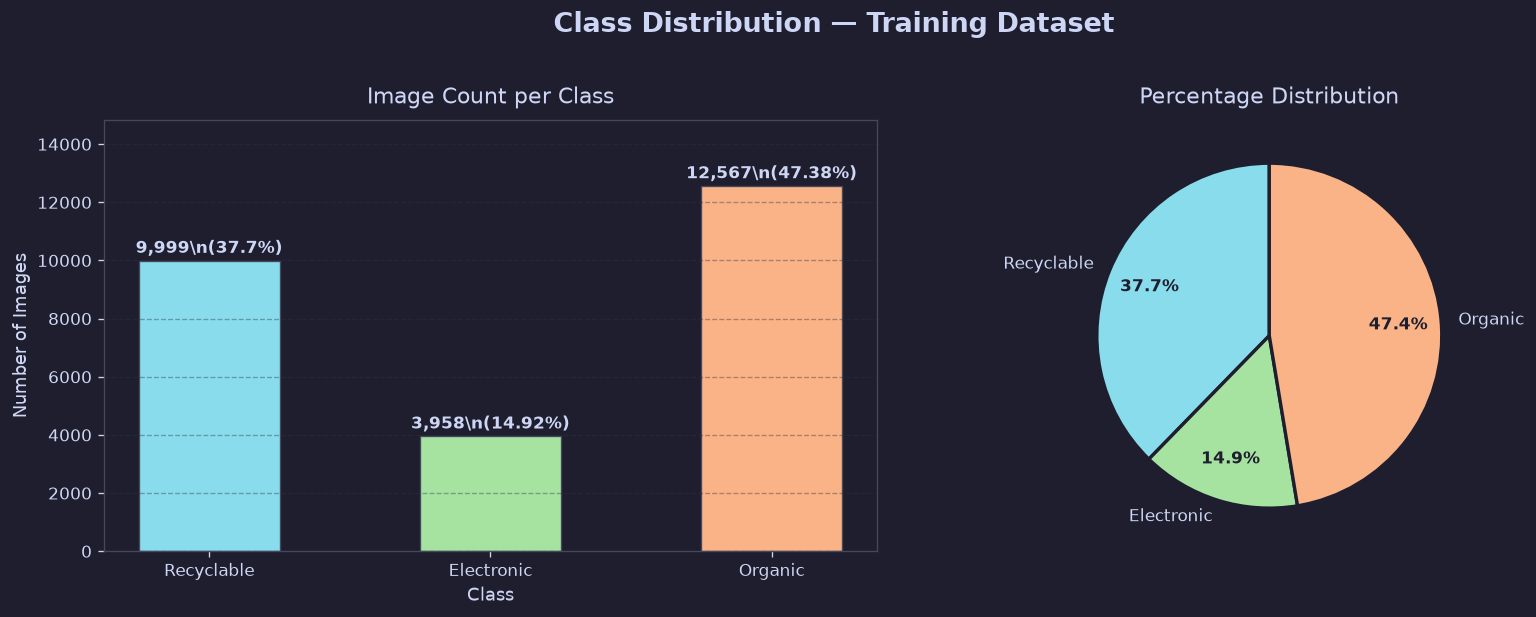

21:32:32 | Saved: D:\Data Analysis\Smart Waste Classification\outputs\figures\eda_class_distribution.png
21:32:32 | Statistik dataset disimpan ke reports.


In [3]:
# ============================================================
# CELL 3 — DATASET SCAN & DISTRIBUTION
# ============================================================

dataset_info, all_image_paths = scan_dataset(TRAIN_DIR, CLASS_NAMES)
total_images = sum(v['image_count'] for v in dataset_info.values())

print('\n' + '='*55)
print(f'  DATASET OVERVIEW — SATRIA DATA 2026 BDC')
print('='*55)
print(f'  Total Classes : {len(dataset_info)}')
print(f'  Total Images  : {total_images:,}')
print('='*55)

# Visualisasi Distribusi Kelas
dist_path = FIGURES_DIR / 'eda_class_distribution.png'
plot_class_distribution(dataset_info, total_images, save_path=dist_path)

# Simpan statistik ke file
df_overview = pd.DataFrame(list(dataset_info.values()))
df_overview.to_csv(REPORTS_DIR / 'eda_dataset_summary.csv', index=False)
logger.info('Statistik dataset disimpan ke reports.')

---
## Step 2 — Image Properties Analysis
Membaca seluruh metadata (ukuran, aspect ratio, warna) untuk memutuskan seberapa besar gambar harus di-resize.

21:32:32 | Membaca properti gambar (membutuhkan waktu)...



Berhasil dibaca : 26,524 gambar
Gagal dibaca    : 0 gambar

📐 Ringkasan Properti Gambar:
          width    height  aspect_ratio  file_size_kb
count  26524.00  26524.00      26524.00      26524.00
mean     304.90    250.22          1.28         47.72
std      417.93    342.72          0.45        471.28
min       51.00     69.00          0.13          0.77
25%      220.00    174.00          1.00          4.79
50%      254.00    194.00          1.25          7.64
75%      276.00    225.00          1.50         11.50
max     8000.00   6000.00          8.70      19262.67


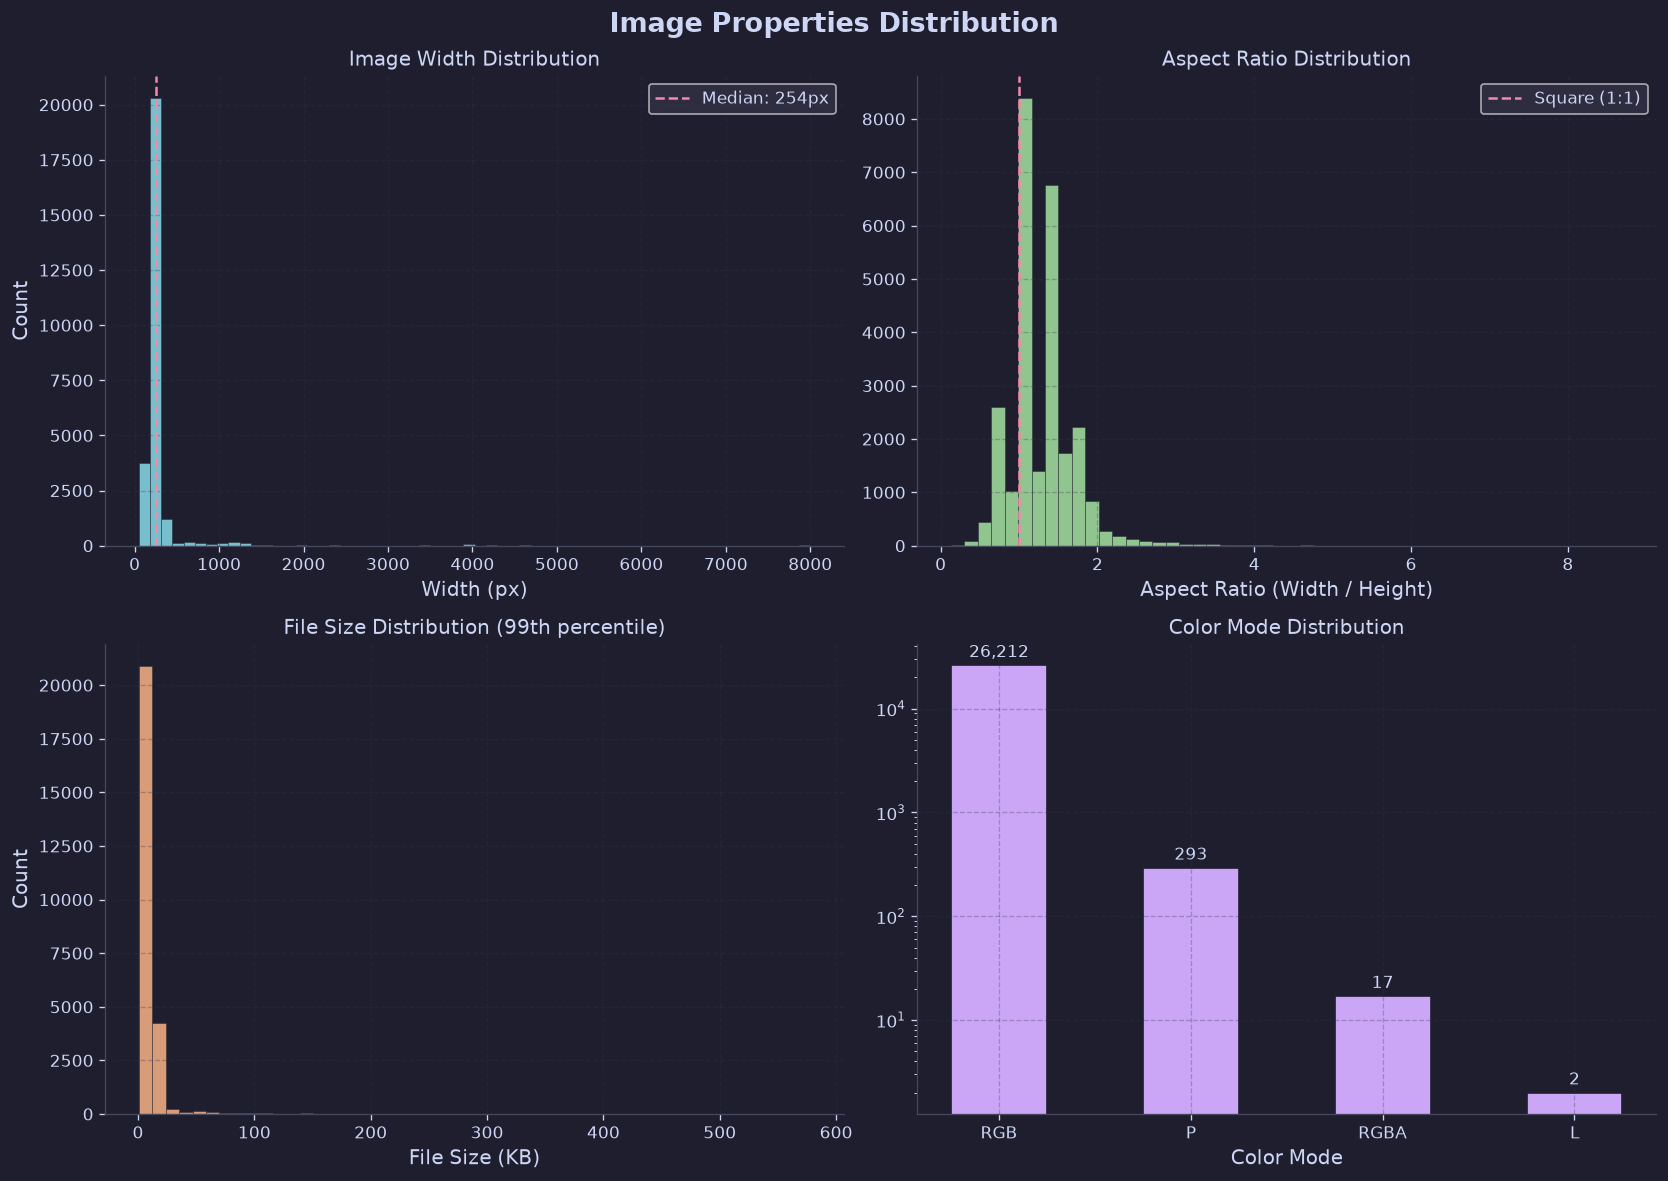

21:35:06 | Saved: D:\Data Analysis\Smart Waste Classification\outputs\figures\eda_image_properties.png


In [4]:
# ============================================================
# CELL 4 — IMAGE PROPERTIES
# ============================================================

logger.info('Membaca properti gambar (membutuhkan waktu)...')
df_props, corrupted_files = get_image_properties_df(all_image_paths, CLASS_NAMES)

print(f'\nBerhasil dibaca : {len(df_props):,} gambar')
print(f'Gagal dibaca    : {len(corrupted_files)} gambar')

print(f'\n📐 Ringkasan Properti Gambar:')
print(df_props[['width', 'height', 'aspect_ratio', 'file_size_kb']].describe().round(2).to_string())

# Visualisasi Properti
props_path = FIGURES_DIR / 'eda_image_properties.png'
plot_image_properties(df_props, save_path=props_path)

---
## Step 3 — Representative Sample Visualization
Menampilkan contoh visual dari tiap kelas untuk melihat karakteristik objek, lighting, dan noise.

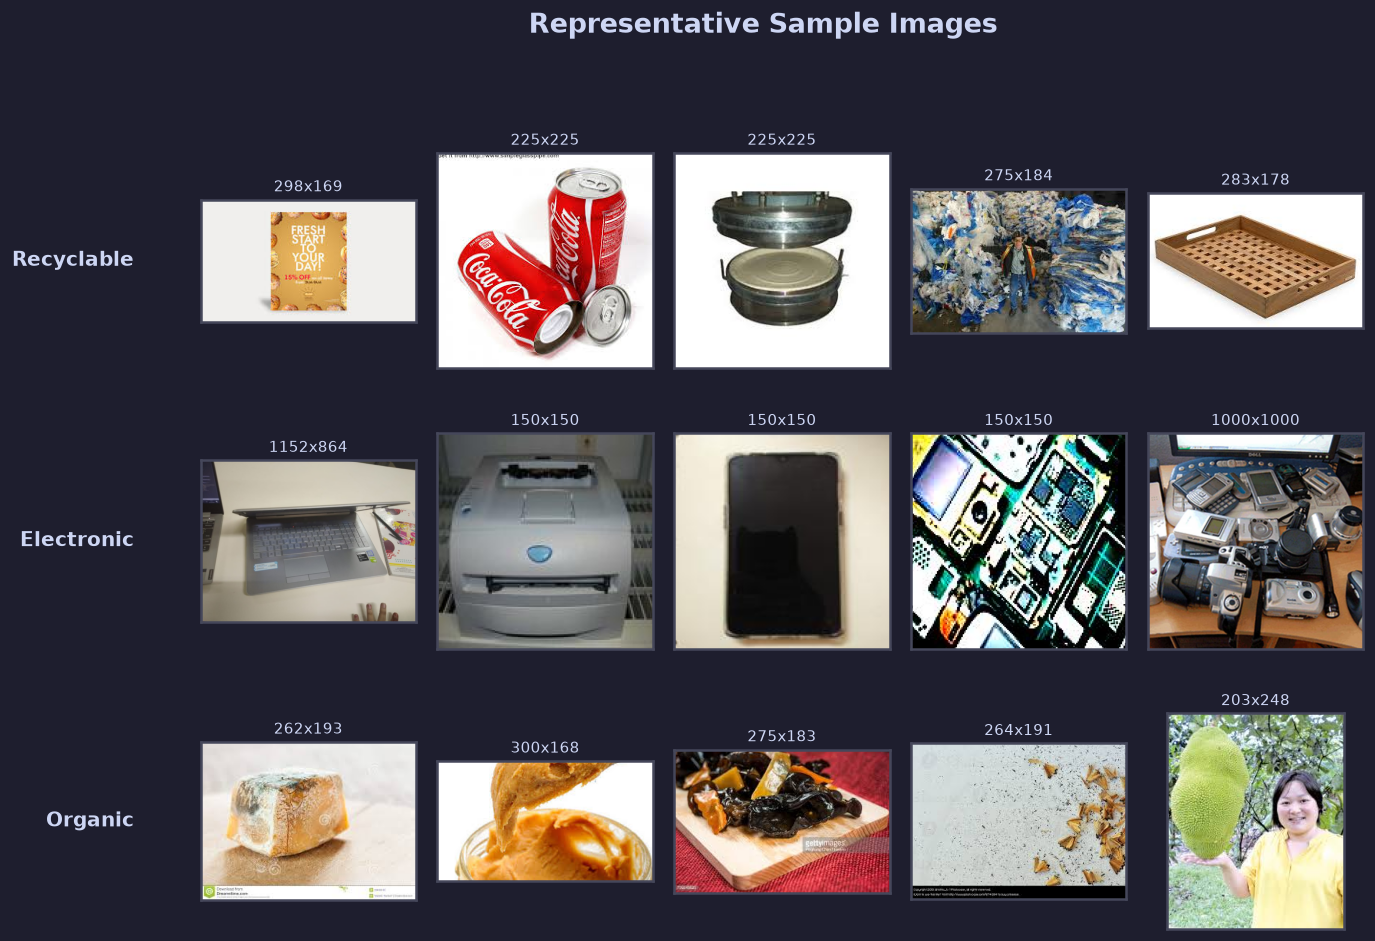

21:35:08 | Saved: D:\Data Analysis\Smart Waste Classification\outputs\figures\eda_sample_images.png


In [5]:
# ============================================================
# CELL 5 — VISUALIZE SAMPLES
# ============================================================

sample_path = FIGURES_DIR / 'eda_sample_images.png'
plot_sample_images(all_image_paths, CLASS_NAMES, save_path=sample_path, n_samples=5)

---
## Step 4 — Duplicates & Corrupted Images Analysis
Mendeteksi file yang sama persis (hash MD5) yang berpotensi menyebabkan *data leakage* jika tersebar di train dan val.

In [6]:
# ============================================================
# CELL 6 — DUPLICATES & CORRUPTED
# ============================================================

logger.info('Mencari duplikat gambar menggunakan hash MD5...')
exact_duplicates, cross_class_duplicates = find_duplicates(all_image_paths)

print('\n' + '='*55)
print('  HASIL DETEKSI ANOMALI DATA')
print('='*55)
print(f'  Gambar Corrupt           : {len(corrupted_files)}')
print(f'  Duplikat (Kelas Sama)    : {sum(len(d["files"])-1 for d in exact_duplicates)} (dari {len(exact_duplicates)} kelompok)')
print(f'  Duplikat (Lintas Kelas)  : {len(cross_class_duplicates)}')
print('='*55)

# Simpan ringkasan anomali
anomaly_report = {
    'corrupted_files': corrupted_files,
    'exact_duplicates': exact_duplicates,
    'cross_class_duplicates': cross_class_duplicates
}
with open(REPORTS_DIR / 'eda_anomalies.json', 'w') as f:
    json.dump(anomaly_report, f, indent=2)
logger.info('Laporan anomali disimpan ke eda_anomalies.json')

21:35:08 | Mencari duplikat gambar menggunakan hash MD5...
21:35:13 | Laporan anomali disimpan ke eda_anomalies.json



  HASIL DETEKSI ANOMALI DATA
  Gambar Corrupt           : 0
  Duplikat (Kelas Sama)    : 61 (dari 61 kelompok)
  Duplikat (Lintas Kelas)  : 1
